# Model 3 Neural Network



## 1 - Packages

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, roc_curve, auc, f1_score, accuracy_score, precision_score, recall_score
from utils import load_split

%matplotlib inline
plt.style.use('./deeplearning.mplstyle')
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)
np.set_printoptions(precision=2)

print("All packages loaded successfully.")

All packages loaded successfully.


## 2 - Loading data

In [10]:
DATA_DIR   = Path("data/processed")

X_train, y_train = load_split("train", DATA_DIR)
X_val,   y_val   = load_split("val", DATA_DIR)
X_test,  y_test  = load_split("test", DATA_DIR)

print ('The shape of X is: ' + str(X_train.shape))
print ('The shape of y is: ' + str(y_train.shape))

The shape of X is: (100778, 41)
The shape of y is: (100778,)


## 3 - Normalising data and converting multiclass to binary

In [11]:
#Scale input data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Integers to one-hot vectors
y_train_multi = to_categorical(y_train, num_classes=40)
y_val_multi   = to_categorical(y_val, num_classes=40)
y_test_multi = to_categorical(y_test, num_classes=40)

# Map Class 16 to 0, all other to 1
y_train_bin = np.where(y_train == 16, 0, 1)
y_val_bin   = np.where(y_val == 16, 0, 1)
y_test_bin = np.where(y_test == 16, 0, 1)

# Multiclass to binary
y_binary = np.where(y_train == 16, 0, 1)
print("Class counts:")
print(pd.Series(y_binary).value_counts())
# You should now see only 0s and 1s

Class counts:
0    53874
1    46904
Name: count, dtype: int64


## 4 - Multi-classification

### 4.1 - Training model 3MCv1: Neural network with 20 training cycles and no regularisation 

In [12]:
input_shape = (X_train_scaled.shape[1],) 
num_classes = 40
print("--- Building Model 3MCv1 ---")
# Build Model 1 (Neural network with 20 training cycles, no early stopping)
model_3MCv1 = Sequential([
    Dense(128, activation='relu', input_shape=input_shape),
    Dropout(0.3), 
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_3MCv1.compile(optimizer='adam', 
                loss='categorical_crossentropy', 
                metrics=['accuracy'])

# Train
print("Training  Model 3MCv1...")
history_3MCv1 = model_3MCv1.fit(
    X_train_scaled, y_train_multi,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_scaled, y_val_multi)
)

--- Building Model 3MCv1 ---
Training  Model 3MCv1...
Epoch 1/50


c:\Users\marti\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9558 - loss: 0.1791 - val_accuracy: 0.9870 - val_loss: 0.0436
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9837 - loss: 0.0604 - val_accuracy: 0.9897 - val_loss: 0.0348
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9864 - loss: 0.0482 - val_accuracy: 0.9908 - val_loss: 0.0309
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9874 - loss: 0.0426 - val_accuracy: 0.9905 - val_loss: 0.0293
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9880 - loss: 0.0390 - val_accuracy: 0.9921 - val_loss: 0.0279
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9895 - loss: 0.0359 - val_accuracy: 0.9924 - val_loss: 0.0266
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9899 - loss: 0.0338 - val_accuracy: 0.9931 - val_loss: 0.0250
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9908 - loss: 0.0307 - val_accurac

### 4.2 - Prediction and accuracy Model 3MCv1

In [13]:
test_loss_3MCv1, test_acc_3MCv1 = model_3MCv1.evaluate(X_test_scaled, y_test_multi, verbose=2)
print(f"\nTest Accuracy: {test_acc_3MCv1*100:.2f}%")

y_pred_3MCv1_probs = model_3MCv1.predict(X_test_scaled)

y_pred_3MCv1 = np.argmax(y_pred_3MCv1_probs, axis=1)
y_true_integers = np.argmax(y_test_multi, axis=1)

print("--- Classification Report 3MCv1 ---")
report = classification_report(y_true_integers, y_pred_3MCv1, output_dict=True)
print(classification_report(y_true_integers, y_pred_3MCv1))

705/705 - 1s - 779us/step - accuracy: 0.7110 - loss: 16.1183

Test Accuracy: 71.10%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 703us/step
--- Classification Report 3MCv1 ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       0.99      0.92      0.95       359
           2       0.67      0.20      0.31        20
           3       1.00      0.33      0.50         3
           4       0.00      0.00      0.00      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.81      0.98      0.88       141
           8       0.70      1.00      0.82         7
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00        17
          14       0.93   

c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-pa

### 4.3 - Training model 3MCv2: Neural network with L1 regularisation with early stopping mechanism

In [14]:
print("--- Building Model 3MCv2 (L1 Regularized) ---")

model_3MCv2 = Sequential([
    Dense(128, activation='relu', 
                 input_shape=input_shape,
                 kernel_regularizer=tf.keras.regularizers.l1(0.001)), 
    Dropout(0.3), 
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_3MCv2.compile(optimizer='adam', 
                loss='categorical_crossentropy', 
                metrics=['accuracy'])

print("Starting training...")
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

history_3MCv2 = model_3MCv2.fit(
    X_train_scaled, y_train_multi,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_scaled, y_val_multi),
    callbacks=[early_stopping],
    verbose=1
)


--- Building Model 3MCv2 (L1 Regularized) ---
Starting training...
Epoch 1/50


c:\Users\marti\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9514 - loss: 0.3807 - val_accuracy: 0.9839 - val_loss: 0.1484
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9771 - loss: 0.1520 - val_accuracy: 0.9872 - val_loss: 0.1090
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9806 - loss: 0.1278 - val_accuracy: 0.9893 - val_loss: 0.0977
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9826 - loss: 0.1166 - val_accuracy: 0.9862 - val_loss: 0.0936
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9837 - loss: 0.1079 - val_accuracy: 0.9887 - val_loss: 0.0894
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9834 - loss: 0.1054 - val_accuracy: 0.9902 - val_loss: 0.0818
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9838 - loss: 0.1006 - val_accuracy: 0.9892 - val_loss: 0.0861
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9844 - loss: 0.0977 - val_accurac

### 4.4 - Prediction and accuracy Model 3MCv2

In [15]:
test_loss_3MCv2, test_acc_3MCv2 = model_3MCv2.evaluate(X_test_scaled, y_test_multi, verbose=2)
print(f"\nTest Accuracy: {test_acc_3MCv2*100:.2f}%")

y_pred_3MCv2_probs = model_3MCv2.predict(X_test_scaled)

y_pred_3MCv2 = np.argmax(y_pred_3MCv2_probs, axis=1)
y_true_integers = np.argmax(y_test_multi, axis=1)

print("--- Classification Report 3MCv2 ---")
report = classification_report(y_true_integers, y_pred_3MCv2, output_dict=True)
print(classification_report(y_true_integers, y_pred_3MCv2))

705/705 - 1s - 788us/step - accuracy: 0.7109 - loss: 5.0063

Test Accuracy: 71.09%
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step
--- Classification Report 3MCv2 ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       0.99      0.98      0.99       359
           2       0.00      0.00      0.00        20
           3       0.00      0.00      0.00         3
           4       1.00      0.01      0.02      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.63      0.97      0.76       141
           8       1.00      1.00      1.00         7
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00        17
          14       0.95    

c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-pa

### 4.5 - Accuracy and loss comparison of both multi-classclassification models over epochs

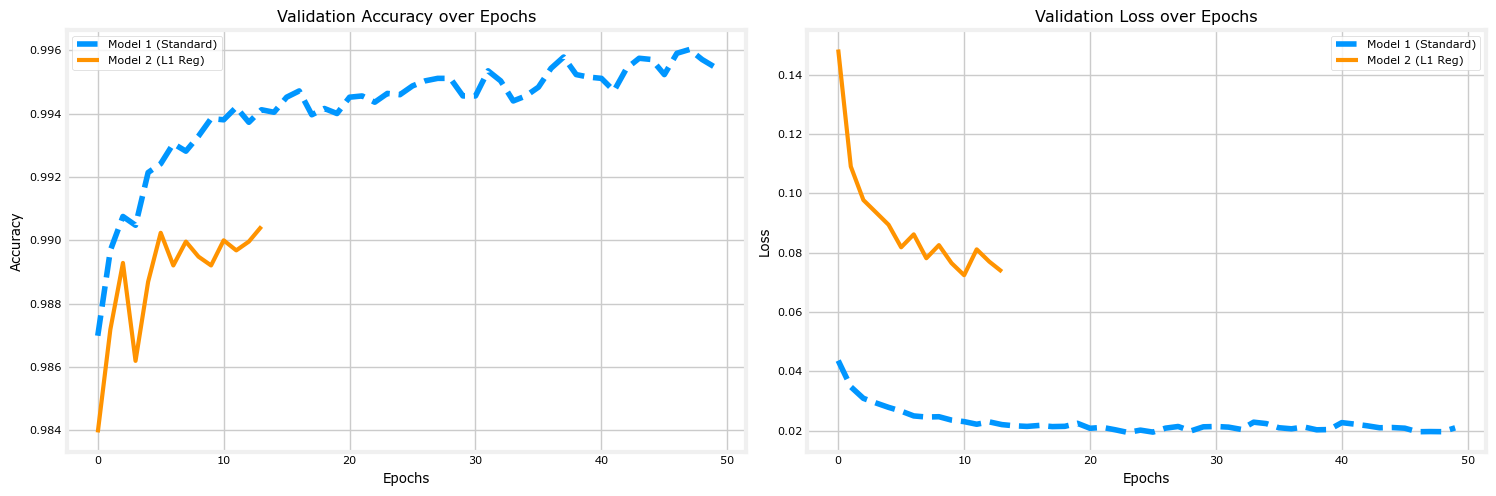

--- Final Project Results ---
          Metric Model 3MCv1 (Standard) Model 3MCv2 (L1 Regularized)
0  Test Accuracy                 71.10%                       71.09%
1  Features Used         All 41 (Dense)     All 41 (Sparse/Filtered)


In [16]:
plt.close('all') 
# Create a clean figure with two subplots (Accuracy and Loss)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Validation Accuracy Comparison
ax1.plot(history_3MCv1.history['val_accuracy'], label='Model 1 (Standard)', linestyle='--')
ax1.plot(history_3MCv2.history['val_accuracy'], label='Model 2 (L1 Reg)', linewidth=3)
ax1.set_title('Validation Accuracy over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot 2: Validation Loss Comparison
ax2.plot(history_3MCv1.history['val_loss'], label='Model 1 (Standard)', linestyle='--')
ax2.plot(history_3MCv2.history['val_loss'], label='Model 2 (L1 Reg)', linewidth=3)
ax2.set_title('Validation Loss over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout() 
plt.show()

results_df = pd.DataFrame({
    "Metric": ["Test Accuracy", "Features Used"],
    "Model 3MCv1 (Standard)": [f"{test_acc_3MCv1*100:.2f}%", "All 41 (Dense)"],
    "Model 3MCv2 (L1 Regularized)": [f"{test_acc_3MCv2*100:.2f}%", "All 41 (Sparse/Filtered)"]
})

print("--- Final Project Results ---")
print(results_df)

## 5 - Binary classification

### 5.1 - Training model 3BINv1: Neural network with 20 training cycles and no regularisation 

In [17]:
print("--- Building Model 3BINv1 ---")
model_bin_3BINv1 = Sequential([
    Dense(128, activation='relu', input_shape=input_shape),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_bin_3BINv1.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

print("Training  Model 3BINv1...")
history_bin_3BINv1 = model_bin_3BINv1.fit(
    X_train_scaled, y_train_bin,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_scaled, y_val_bin),
    verbose=1
)

--- Building Model 3BINv1 ---
Training  Model 3BINv1...
Epoch 1/50


c:\Users\marti\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9748 - loss: 0.0697 - val_accuracy: 0.9901 - val_loss: 0.0295
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9875 - loss: 0.0364 - val_accuracy: 0.9918 - val_loss: 0.0244
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9893 - loss: 0.0301 - val_accuracy: 0.9927 - val_loss: 0.0212
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9905 - loss: 0.0265 - val_accuracy: 0.9916 - val_loss: 0.0212
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9914 - loss: 0.0245 - val_accuracy: 0.9932 - val_loss: 0.0199
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9917 - loss: 0.0226 - val_accuracy: 0.9941 - val_loss: 0.0179
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9928 - loss: 0.0209 - val_accuracy: 0.9946 - val_loss: 0.0161
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9928 - loss: 0.0203 - val_accurac

### 5.2 Prediction and accuracy Model 3BINv1

In [18]:
test_loss_3BINv1, test_acc_3BINv1 = model_bin_3BINv1.evaluate(X_test_scaled, y_test_bin, verbose=2)
print(f"Test Accuracy: {test_acc_3BINv1*100:.2f}%")

y_pred_3BINv1_probs = model_bin_3BINv1.predict(X_test_scaled)

y_pred_3BINv1 = (y_pred_3BINv1_probs > 0.5).astype("int32")

print("--- Classification Report 3MCv1 ---")
print(classification_report(y_test_bin, y_pred_3BINv1, target_names=['Normal', 'Attack']))


705/705 - 1s - 997us/step - accuracy: 0.7861 - loss: 2.4340
Test Accuracy: 78.61%
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step
--- Classification Report 3MCv1 ---
              precision    recall  f1-score   support

      Normal       0.67      0.98      0.80      9711
      Attack       0.97      0.64      0.77     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.78     22544



### 5.3 Training model 3BINv2: Neural network with L1 regularisation with early stopping mechanism

In [19]:
model_bin_3BINv2 = Sequential([
    Dense(128, activation='relu', 
          input_shape=input_shape,
          kernel_regularizer=tf.keras.regularizers.l1(0.001)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_bin_3BINv2.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

early_stopping_bin = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Training 3BINv2...")
history_bin_3BINv2 = model_bin_3BINv2.fit(
    X_train_scaled, y_train_bin,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_scaled, y_val_bin),
    callbacks=[early_stopping_bin],
    verbose=1
)

Training 3BINv2...
Epoch 1/50


c:\Users\marti\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9731 - loss: 0.1860 - val_accuracy: 0.9848 - val_loss: 0.0875
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9842 - loss: 0.0834 - val_accuracy: 0.9872 - val_loss: 0.0712
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9853 - loss: 0.0742 - val_accuracy: 0.9895 - val_loss: 0.0593
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9860 - loss: 0.0682 - val_accuracy: 0.9894 - val_loss: 0.0564
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9858 - loss: 0.0685 - val_accuracy: 0.9903 - val_loss: 0.0544
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9862 - loss: 0.0645 - val_accuracy: 0.9903 - val_loss: 0.0556
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9861 - loss: 0.0648 - val_accuracy: 0.9906 - val_loss: 0.0542
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9861 - loss: 0.0626 - val_accurac

### 5.4 Prediction and accuracy Model 3BINv2

In [20]:
test_loss_3BINv2, test_acc_3BINv2 = model_bin_3BINv2.evaluate(X_test_scaled, y_test_bin, verbose=2)
print(f"Test Accuracy: {test_acc_3BINv2*100:.2f}%")

y_pred_3BINv2_probs = model_bin_3BINv2.predict(X_test_scaled)

y_pred_3BINv2 = (y_pred_3BINv2_probs > 0.5).astype("int32")

print("--- Classification Report 3BINv2 ---")
print(classification_report(y_test_bin, y_pred_3BINv2, target_names=['Normal', 'Attack']))

705/705 - 1s - 864us/step - accuracy: 0.7944 - loss: 1.1232
Test Accuracy: 79.44%
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step
--- Classification Report 3BINv2 ---
              precision    recall  f1-score   support

      Normal       0.68      0.98      0.80      9711
      Attack       0.97      0.66      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.83      0.82      0.79     22544
weighted avg       0.85      0.79      0.79     22544



### 5.5 - Accuracy and loss comparison of both multi-classclassification models over epochs

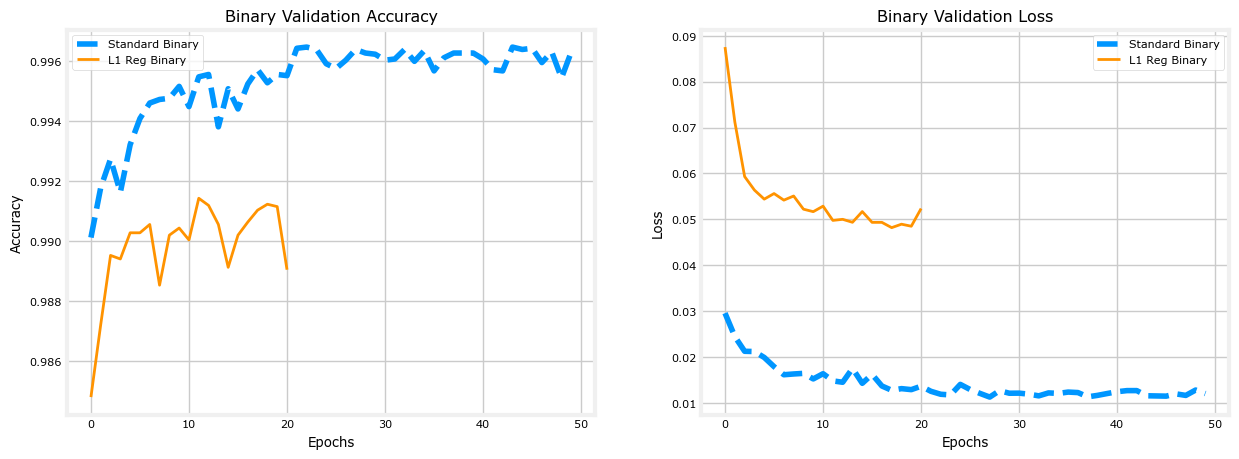

--- Final Project Results ---
          Metric Model 3BINv1 (Standard) Model 3BINv2 (L1 Regularized)
0  Test Accuracy                  78.61%                        79.44%
1  Features Used          All 41 (Dense)      All 41 (Sparse/Filtered)


In [21]:
plt.close('all') 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy Plot
ax1.plot(history_bin_3BINv1.history['val_accuracy'], label='Standard Binary', linestyle='--')
ax1.plot(history_bin_3BINv2.history['val_accuracy'], label='L1 Reg Binary', linewidth=2)
ax1.set_title('Binary Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(history_bin_3BINv1.history['val_loss'], label='Standard Binary', linestyle='--')
ax2.plot(history_bin_3BINv2.history['val_loss'], label='L1 Reg Binary', linewidth=2)
ax2.set_title('Binary Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.show()

results_df = pd.DataFrame({
    "Metric": ["Test Accuracy", "Features Used"],
    "Model 3BINv1 (Standard)": [f"{test_acc_3BINv1*100:.2f}%", "All 41 (Dense)"],
    "Model 3BINv2 (L1 Regularized)": [f"{test_acc_3BINv2*100:.2f}%", "All 41 (Sparse/Filtered)"]
})

print("--- Final Project Results ---")
print(results_df)


## 6 - Visualisation

### 6.1 Visualisation and optimalisation multi-classification

### 6.2 Visualisation and optimalisation binary classification

--- Visualizing Model 3BINv1 (Standard) ---
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step


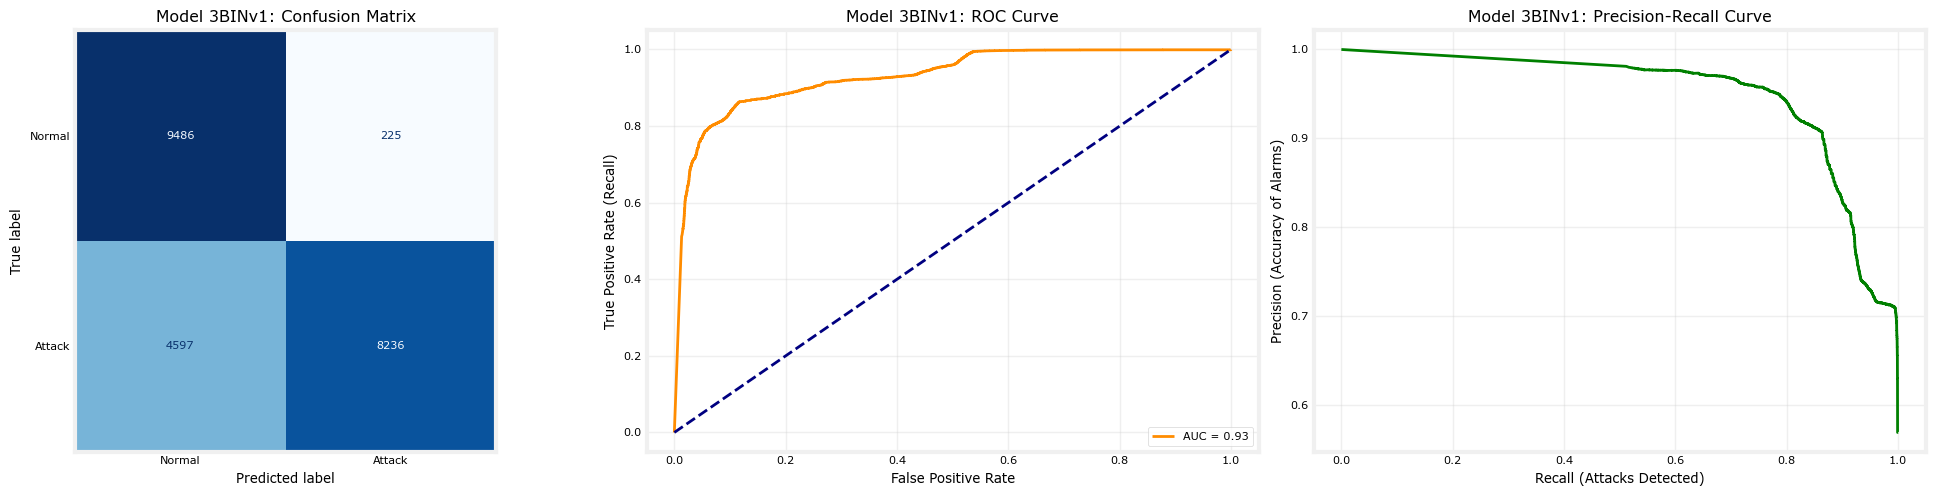


--- Visualizing Model 3BINv2 (L1 Regularized) ---
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step


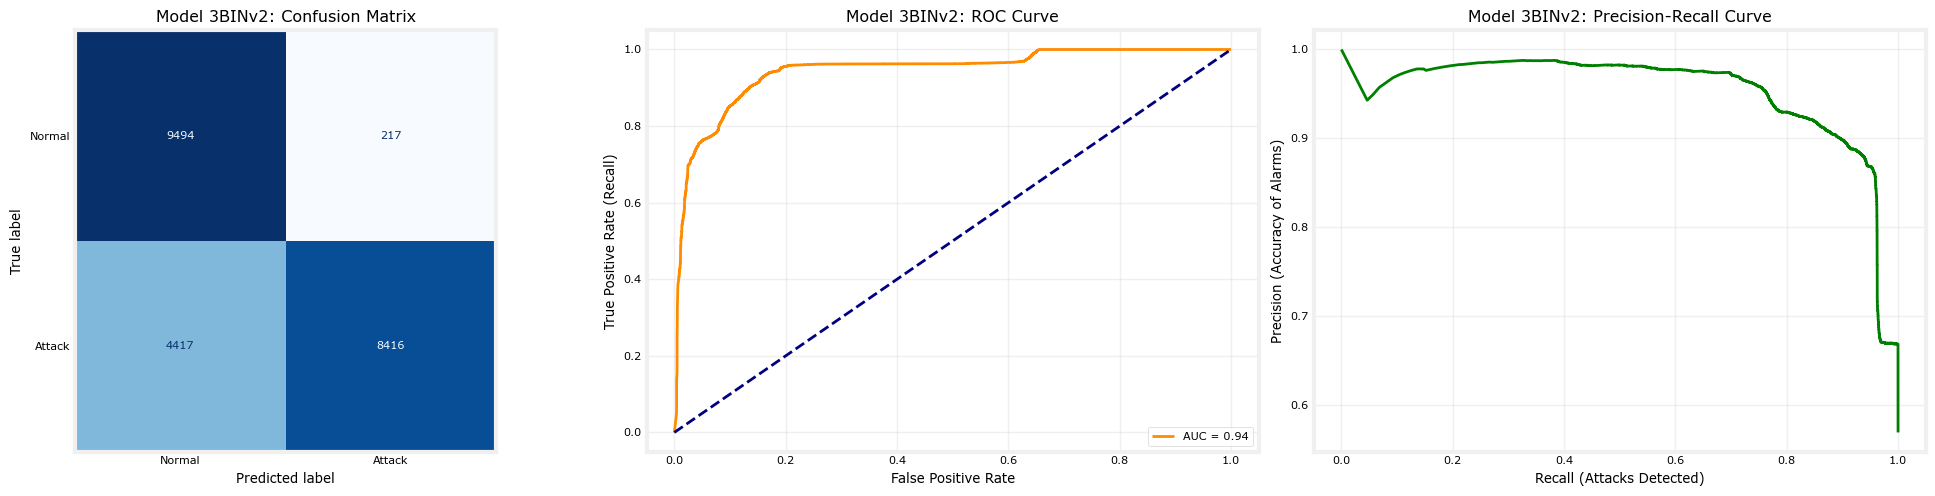

In [28]:
def plot_performance_visuals(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
    disp.plot(cmap='Blues', ax=axes[0], colorbar=False)
    axes[0].set_title(f'{model_name}: Confusion Matrix')

    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate (Recall)')
    axes[1].set_title(f'{model_name}: ROC Curve')
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)

    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
    axes[2].plot(recall, precision, color='green', lw=2)
    axes[2].set_xlabel('Recall (Attacks Detected)')
    axes[2].set_ylabel('Precision (Accuracy of Alarms)')
    axes[2].set_title(f'{model_name}: Precision-Recall Curve')
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("--- Visualizing Model 3BINv1 (Standard) ---")
plot_performance_visuals(model_bin_3BINv1, X_test_scaled, y_test_bin, "Model 3BINv1")

print("\n--- Visualizing Model 3BINv2 (L1 Regularized) ---")
plot_performance_visuals(model_bin_3BINv2, X_test_scaled, y_test_bin, "Model 3BINv2")

In [29]:
def find_optimal_threshold(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test).ravel()
    thresholds = np.arange(0.0, 1.0, 0.01)
    f1_scores = [f1_score(y_test, (y_pred_prob > t).astype(int)) for t in thresholds]
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    print(f"\n--- {model_name} Optimization ---")
    print(f"Optimal Threshold: {best_threshold:.2f} | Best F1 Score: {best_f1:.2f}")
    return best_threshold

thresh_v1 = find_optimal_threshold(model_bin_3BINv1, X_test_scaled, y_test_bin, "Model 3BINv1")
thresh_v2 = find_optimal_threshold(model_bin_3BINv2, X_test_scaled, y_test_bin, "Model 3BINv2")

y_pred_opt_v1 = (model_bin_3BINv1.predict(X_test_scaled).ravel() > thresh_v1).astype(int)
y_pred_opt_v2 = (model_bin_3BINv2.predict(X_test_scaled).ravel() > thresh_v2).astype(int)

print(f"\n=== Final Report: Model 3BINv1 (Threshold {thresh_v1:.2f}) ===")
print(f"Accuracy: {accuracy_score(y_test_bin, y_pred_opt_v1) * 100:.2f}%")
print(classification_report(y_test_bin, y_pred_opt_v1, target_names=['Normal', 'Attack']))

print(f"\n=== Final Report: Model 3BINv2 (Threshold {thresh_v2:.2f}) ===")
print(f"Accuracy: {accuracy_score(y_test_bin, y_pred_opt_v2) * 100:.2f}%")
print(classification_report(y_test_bin, y_pred_opt_v2, target_names=['Normal', 'Attack']))

705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 655us/step

--- Model 3BINv1 Optimization ---
Optimal Threshold: 0.01 | Best F1 Score: 0.84
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step

--- Model 3BINv2 Optimization ---
Optimal Threshold: 0.01 | Best F1 Score: 0.87
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step

=== Final Report: Model 3BINv1 (Threshold 0.01) ===
Accuracy: 83.60%
              precision    recall  f1-score   support

      Normal       0.74      0.96      0.83      9711
      Attack       0.96      0.74      0.84     12833

    accuracy                           0.84     22544
   macro avg       0.85      0.85      0.84     22544
weighted avg       0.86      0.84      0.84     22544


=== Final Report: Model 3BINv2 (Threshold 0.01) ===
Accuracy: 85.69%
              precision    recall  f1-score   support

      Normal       0.79      0.92      0.85      9711
      Attack       0.93      0.81      0.87     12833

    accuracy                       

705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 489us/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 790us/step


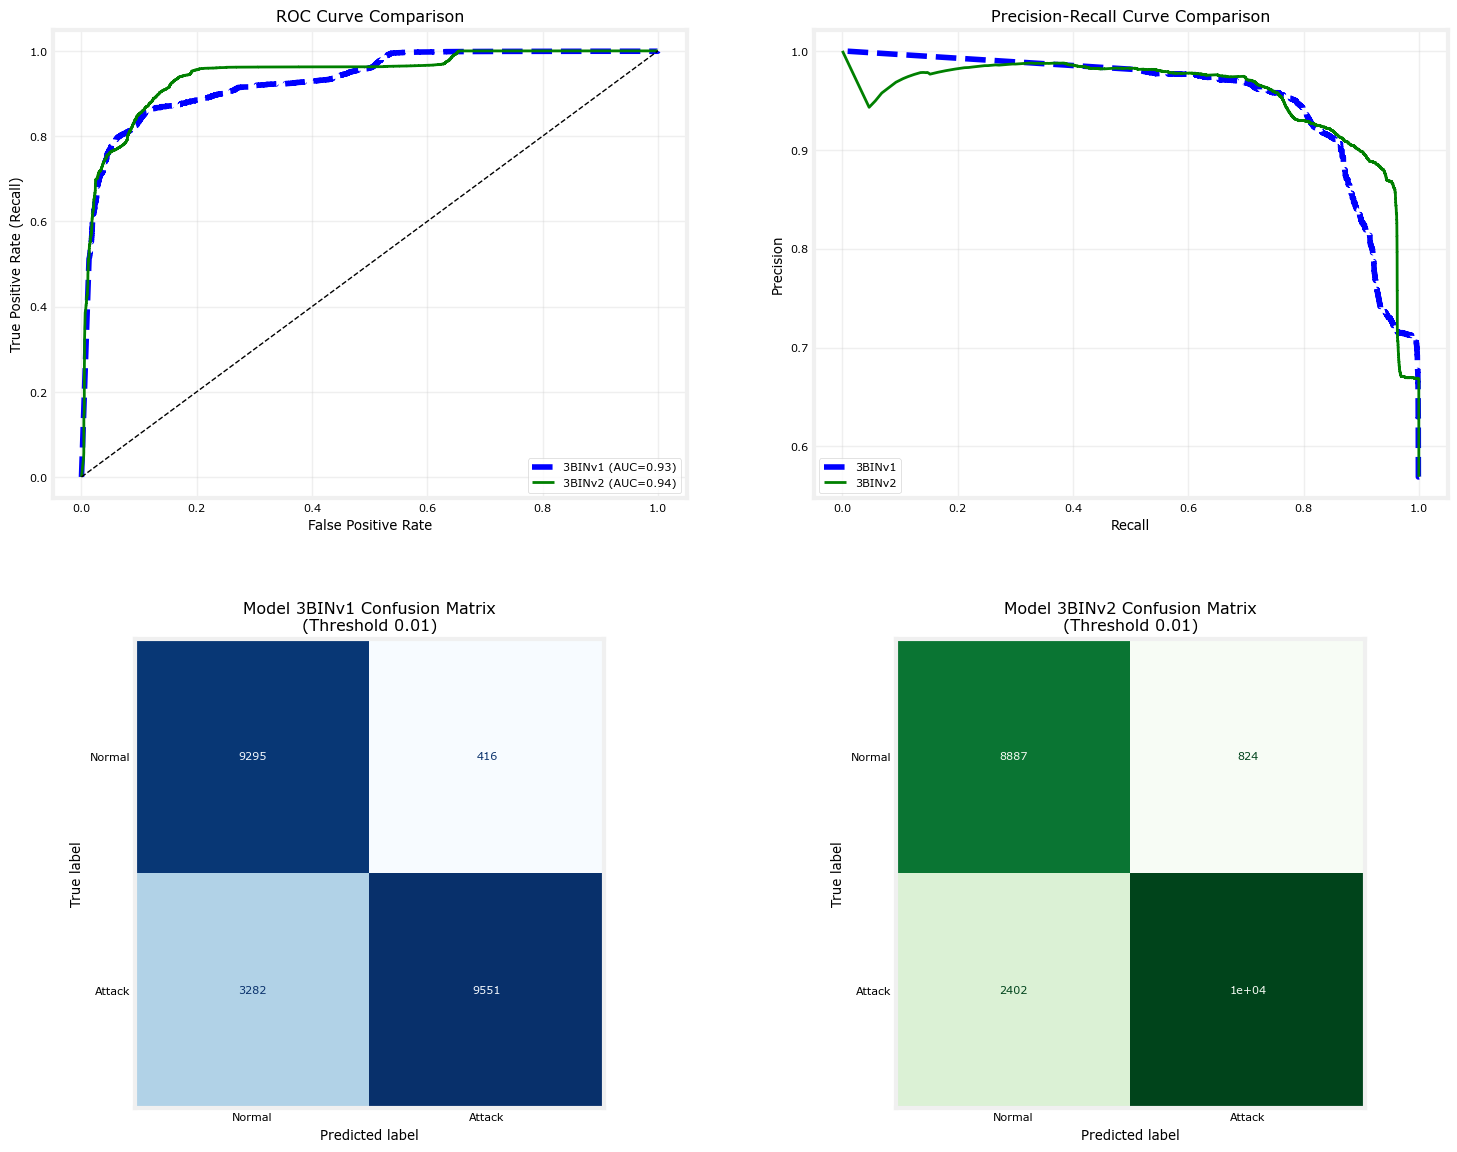

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve

y_prob_v1 = model_bin_3BINv1.predict(X_test_scaled).ravel()
y_prob_v2 = model_bin_3BINv2.predict(X_test_scaled).ravel()

t1 = locals().get('thresh_v1', 0.01)
t2 = locals().get('thresh_v2', 0.01)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plt.subplots_adjust(hspace=0.3)

# Top Left: ROC Comparison
fpr1, tpr1, _ = roc_curve(y_test_bin, y_prob_v1)
fpr2, tpr2, _ = roc_curve(y_test_bin, y_prob_v2)
axes[0, 0].plot(fpr1, tpr1, linestyle='--', color='blue', label=f'3BINv1 (AUC={auc(fpr1, tpr1):.2f})')
axes[0, 0].plot(fpr2, tpr2, linewidth=2, color='green', label=f'3BINv2 (AUC={auc(fpr2, tpr2):.2f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].set_title('ROC Curve Comparison')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate (Recall)')
axes[0, 0].legend(loc="lower right")
axes[0, 0].grid(alpha=0.3)

# Top Right: Precision-Recall Comparison
p1, r1, _ = precision_recall_curve(y_test_bin, y_prob_v1)
p2, r2, _ = precision_recall_curve(y_test_bin, y_prob_v2)
axes[0, 1].plot(r1, p1, linestyle='--', color='blue', label='3BINv1')
axes[0, 1].plot(r2, p2, linewidth=2, color='green', label='3BINv2')
axes[0, 1].set_title('Precision-Recall Curve Comparison')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].legend(loc="lower left")
axes[0, 1].grid(alpha=0.3)

# Bottom Left: Confusion Matrix 3BINv1
cm_v1 = confusion_matrix(y_test_bin, (y_prob_v1 > t1).astype(int))
disp_v1 = ConfusionMatrixDisplay(confusion_matrix=cm_v1, display_labels=['Normal', 'Attack'])
disp_v1.plot(cmap='Blues', ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title(f'Model 3BINv1 Confusion Matrix\n(Threshold {t1:.2f})')

# Bottom Right: Confusion Matrix 3BINv2
cm_v2 = confusion_matrix(y_test_bin, (y_prob_v2 > t2).astype(int))
disp_v2 = ConfusionMatrixDisplay(confusion_matrix=cm_v2, display_labels=['Normal', 'Attack'])
disp_v2.plot(cmap='Greens', ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title(f'Model 3BINv2 Confusion Matrix\n(Threshold {t2:.2f})')

plt.show()